# **Swiss Railway:** Complex Network Creation

In [2]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

## **Data Analysis**

We have obtained two csv files from the website https://figshare.com/articles/dataset/Four_representations_of_the_Swiss_railway_network/29609615/2. One of them contains the data about the nodes and the other about the edges that connect those nodes.

In the following sections we will enter into detail about each one of those files.

### Node data

The node data of our network is in the file `nodelist.csv`. Each node represents one of the 1626 stations of the Swiss Railway network for all the rail companys in the country. Moreover, we have information available of the city where the station is located, the company that controls the station, the geographic location and about the average daily traffic of each node.

In [3]:
df_nodes = pd.read_csv("data/nodelist.csv", delimiter=';')

display(df_nodes)
display(df_nodes.dtypes)

,BPUIC,STATION_NAME,CANTON,MUNICIPALITY,COMPANY,LONGITUDE,LATITUDE,ELEVATION,AVG_DAILY_TRAFFIC,AVG_DAILY_TRAFFIC_WEEKDAYS,AVG_DAILY_TRAFFIC_WEEKENDS,TRAFFIC_VALID
0,8500010,Basel SBB,Basel-Stadt,Basel,Swiss Federal Railways SBB,7.589563,47.547412,276.75,98600.0,105900.0,81900.0,True
1,8500016,Basel St. Johann,Basel-Stadt,Basel,Swiss Federal Railways SBB,7.572529,47.570306,260.50,90.0,100.0,60.0,True
2,8500020,Muttenz,Basel-Landschaft,Muttenz,Swiss Federal Railways SBB,7.647894,47.533591,280.80,5700.0,7000.0,2800.0,True
3,8500021,Pratteln,Basel-Landschaft,Pratteln,Swiss Federal Railways SBB,7.690817,47.522669,289.60,8500.0,9900.0,5200.0,True
4,8500022,Frenkendorf-Füllinsdorf,Basel-Landschaft,Frenkendorf,Swiss Federal Railways SBB,7.719111,47.501470,310.96,3600.0,4100.0,2300.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...
1621,8593774,La Faverge,Vaud,Ormont-Dessus,Transports Publics du Chablais,7.147120,46.354930,1147.30,NaN,NaN,NaN,False
1622,8593775,Les Nicolets,Vaud,Ormont-Dessus,Transports Publics du Chablais,7.119540,46.354460,1096.60,NaN,NaN,NaN,False
1623,8593776,Plan Morier,Vaud,Ormont-Dessus,Transports Publics du Chablais,7.129200,46.353570,1108.60,NaN,NaN,NaN,False
1624,8594258,Langenthal Industrie Nord,Bern,Langenthal,Aare Seeland mobil (rvo),7.786471,47.228557,458.00,NaN,NaN,NaN,False


BPUIC                           int64
STATION_NAME                   object
CANTON                         object
MUNICIPALITY                   object
COMPANY                        object
LONGITUDE                     float64
LATITUDE                      float64
ELEVATION                     float64
AVG_DAILY_TRAFFIC             float64
AVG_DAILY_TRAFFIC_WEEKDAYS    float64
AVG_DAILY_TRAFFIC_WEEKENDS    float64
TRAFFIC_VALID                    bool
dtype: object

#### Visualizations

In [4]:
import plotly.express as px

px.histogram(df_nodes, x='COMPANY').update_xaxes(categoryorder='total descending')

In [5]:
fig = px.scatter_mapbox(
    df_nodes, 
    lat="LATITUDE", 
    lon="LONGITUDE", 
    color="COMPANY",
    hover_name="STATION_NAME",
    zoom=5,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

fig.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_21456\1038476195.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### Edges data

The edges data of our network is in the file `edgelist_SoCha.csv`. Each row represents a directed edge between two stations connected by a direct service that requires no train changes. Moreover, we also have the average time duration of each interstation.

In [6]:
df_edges = pd.read_csv("data/edgelist_SoCha.csv", delimiter=';')

display(df_edges)
display(df_edges.dtypes)

,BPUIC1,BPUIC2,NUM_CONNECTIONS,AVG_DURATION
0,8503000,8500010,88,63.81
1,8503000,8500090,14,81.36
2,8500010,8500090,67,6.07
3,8500090,8500010,67,6.39
4,8500090,8503000,10,100.00
...,...,...,...,...
37940,8503464,8503466,37,6.00
37941,8503464,8503467,37,9.03
37942,8503465,8503466,37,2.00
37943,8503465,8503467,37,5.03


BPUIC1               int64
BPUIC2               int64
NUM_CONNECTIONS      int64
AVG_DURATION       float64
dtype: object

#### Visualizations

In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=1, 
    cols=2, 
    subplot_titles=("NUM_CONNECTIONS distribution", "AVG_DURATION distribution")
)

fig.add_trace(
    go.Violin(
        y=df_edges['NUM_CONNECTIONS'],
        name='Connections',
        box_visible=True, # Muestra la caja (boxplot) dentro del violín
        meanline_visible=True, # Muestra la línea de la media
        fillcolor='lightblue',
        line_color='blue'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Violin(
        y=df_edges['AVG_DURATION'],
        name='Average duration',
        box_visible=True,
        meanline_visible=True,
        fillcolor='lightgreen',
        line_color='green'
    ),
    row=1, col=2
)

fig.update_layout(
    showlegend=False,
    height=500
)

fig.update_yaxes(title_text="Number of connections", row=1, col=1)
fig.update_yaxes(title_text="Duration", row=1, col=2)

fig.show()

In [8]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- DATA PREPARATION ---
# Function to get the top 10 and obtain the station name of each one of them
def get_top_10_with_names(df_conn, column_name, df_n):
    top_10 = df_conn[column_name].value_counts().head(10).reset_index()
    top_10.columns = ['BPUIC', 'COUNT']
    
    top_10 = top_10.merge(df_n[['BPUIC', 'STATION_NAME']], on='BPUIC', how='left')
    
    return top_10

data_bpuic1 = get_top_10_with_names(df_edges, 'BPUIC1', df_nodes)
data_bpuic2 = get_top_10_with_names(df_edges, 'BPUIC2', df_nodes)


# --- VISUALIZATION CREATION ---
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("Top 10 stations with more outgoing tracks", "Top 10 stations with more incoming tracks")
)

fig.add_trace(
    go.Bar(
        x=data_bpuic1['STATION_NAME'], 
        y=data_bpuic1['COUNT'], 
        name='BPUIC1',
        marker_color='royalblue'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=data_bpuic2['STATION_NAME'], 
        y=data_bpuic2['COUNT'], 
        name='BPUIC2',
        marker_color='indianred'
    ),
    row=1, col=2
)

# Ajustamos el diseño
fig.update_layout(
    showlegend=False,
    height=500
)

# Rotamos ligeramente los nombres del eje X para que se lean bien si son muy largos
fig.update_xaxes(tickangle=-45)
fig.update_yaxes(title_text="count", row=1, col=1)
fig.update_yaxes(title_text="count", row=1, col=2)

fig.show()

### Are there connections between stations belonging to different companies? **YES**

In [9]:
import pandas as pd

# We add a column COMPANY1 that informs of the company of the origin station
df_edges_aux = df_edges.merge(
    df_nodes[['BPUIC', 'COMPANY']], 
    left_on='BPUIC1', 
    right_on='BPUIC', 
    how='left'
).rename(columns={'COMPANY': 'COMPANY1'}).drop(columns=['BPUIC'])

# We add COMPANY2 with the company of the destination station
df_edges_aux = df_edges_aux.merge(
    df_nodes[['BPUIC', 'COMPANY']], 
    left_on='BPUIC2', 
    right_on='BPUIC', 
    how='left'
).rename(columns={'COMPANY': 'COMPANY2'}).drop(columns=['BPUIC'])

mixed_connections = df_edges_aux[df_edges_aux['COMPANY1'] != df_edges_aux['COMPANY2']]

print(f"We have {len(mixed_connections)} connections between different companies.")
display(mixed_connections.head())

We have 4830 connections between different companies.


,BPUIC1,BPUIC2,NUM_CONNECTIONS,AVG_DURATION,COMPANY1,COMPANY2
1,8503000,8500090,14,81.36,Swiss Federal Railways SBB,Deutsche Eisenbahn-Infrastruktur in der Schweiz
2,8500010,8500090,67,6.07,Swiss Federal Railways SBB,Deutsche Eisenbahn-Infrastruktur in der Schweiz
3,8500090,8500010,67,6.39,Deutsche Eisenbahn-Infrastruktur in der Schweiz,Swiss Federal Railways SBB
4,8500090,8503000,10,100.00,Deutsche Eisenbahn-Infrastruktur in der Schweiz,Swiss Federal Railways SBB
6,8503424,8500090,17,73.18,Swiss Federal Railways SBB,Deutsche Eisenbahn-Infrastruktur in der Schweiz


## **Network creation**

### General information

In [10]:
# CREATE A REPRESENTATION
G=nx.from_pandas_edgelist(df_edges,source='BPUIC1',target='BPUIC2', edge_attr='AVG_DURATION', create_using=nx.DiGraph())
adj_matrix=nx.to_numpy_array(G)
# According to Networkx documentation: "For directed graphs, explicitly mention create_using=nx.DiGraph, 
#                                       and entry i,j of df corresponds to an edge from i to j." So the 
#                                       rows account for origins and the columns for destinations.

# INFO ABOUT THE NETWORK
n_nodes=G.number_of_nodes()
n_edges=G.number_of_edges()
print("-" * 10 + 'INFORMATION ABOUT THE NETWORK'+"-" * 10)
print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Matrix shape: {adj_matrix.shape}")

#SPARSITY
print('\n'+"-" * 10 + 'SPARSITY'+"-" * 10)
max_num_edges=n_nodes*(n_nodes-1)
proportion=n_edges/max_num_edges
print(f"Number of existing links / number total potential links: {proportion*100:.4f}%")
print(f"Sparsity: {(1-proportion)*100:.4f}%")



----------INFORMATION ABOUT THE NETWORK----------
Number of nodes: 1626
Number of edges: 37945
Matrix shape: (1626, 1626)

----------SPARSITY----------
Number of existing links / number total potential links: 1.4361%
Sparsity: 98.5639%


### Network visualization

We present a visualization of the whole network. Eventhough it is a directed network we represent the undirected network for two reasons: 
1. Since it's a very crowded map, the directions of the edges would be barely visible.
2. An undirected network still shows where there is more train movement (connections).

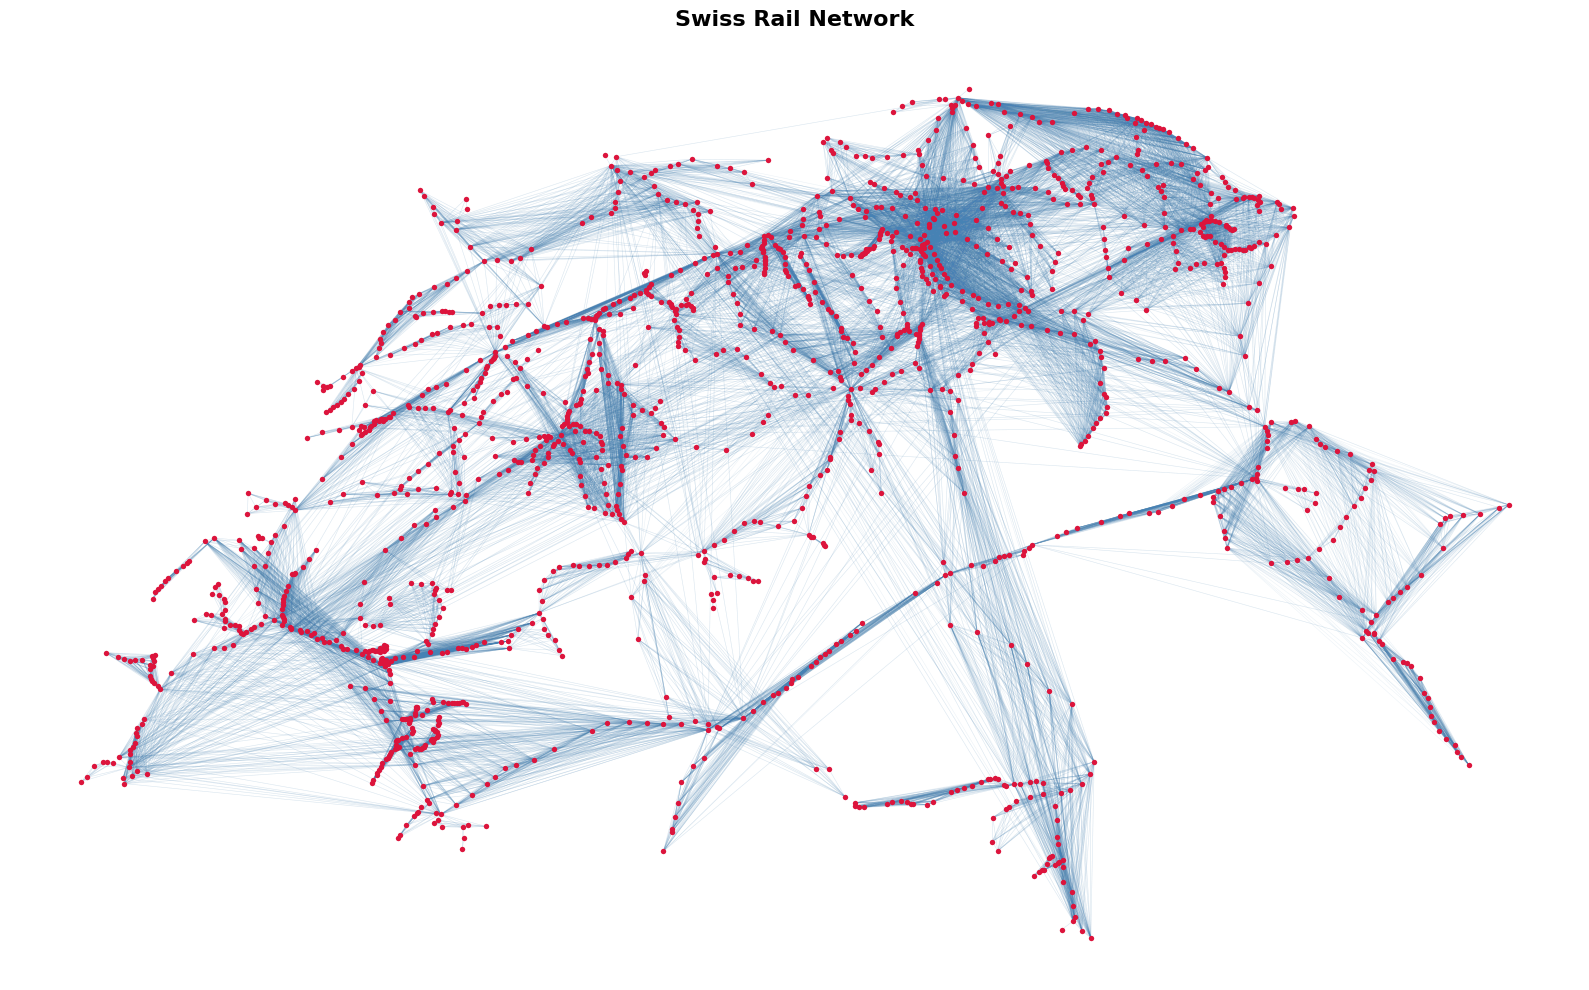

In [11]:
pos = {row['BPUIC']: (row['LONGITUDE'], row['LATITUDE']) for _, row in df_nodes.iterrows()}
fig, ax = plt.subplots(figsize=(16, 10), facecolor='white')

for u, v in G.edges():
    if u in pos and v in pos:
        x = [pos[u][0], pos[v][0]]
        y = [pos[u][1], pos[v][1]]
        ax.plot(x, y, color='steelblue', alpha=0.1, linewidth=0.4)

x_coords = [pos[n][0] for n in G.nodes() if n in pos]
y_coords = [pos[n][1] for n in G.nodes() if n in pos]
ax.scatter(x_coords, y_coords, s=15, c='crimson', zorder=5, linewidths=0)

ax.set_title("Swiss Rail Network", fontsize=16, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

As we can see, the obtained representation of the network clearly resembles the shape of Switzerland. It also shows that the areas with more train connections (areas in darker blue) are around the biggest and most important cities of the country, as we could expect, such as Lausanne, Bern or Zürich. 

In the next plot we can see more clearly where each station (node) is located and that the network covers a wide range of the country.

In [12]:
fig = px.scatter_mapbox(
    df_nodes, 
    lat="LATITUDE", 
    lon="LONGITUDE",
    hover_name="STATION_NAME",
    zoom=7,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

fig.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_21456\1490763764.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


### In and Out degree vectors

In [13]:
#OUT DEGREE VECTOR
print('\n'+"-" * 10 + 'OUT DEGREE VECTOR'+"-" * 10)
print('TOP 10 ESTATIONS WITH MORE OUT-LINKS AND THEIR MUNICIPALITY')
print('Format: Station name, Municipality')
out_degree_vector=adj_matrix @ np.ones(n_nodes)
out_degree_vector_idx=list(zip(out_degree_vector, np.arange(0, n_nodes)))
out_ordered_deg_vect_idx = sorted(out_degree_vector_idx, key=lambda x: x[0], reverse=True)
out_ordered_deg_vect_idx = [(int(deg), int(idx)) for deg, idx in out_ordered_deg_vect_idx]
nodes=out_ordered_deg_vect_idx[:10]
node_list=list(G.nodes())
i=1
for deg,node in nodes:
    node_id=node_list[node]
    municipality = df_nodes.loc[df_nodes['BPUIC'] == node_id, 'MUNICIPALITY'].values[0]
    station= df_nodes.loc[df_nodes['BPUIC'] == node_id, 'STATION_NAME'].values[0]
    print(f'{i}. {station}, {municipality}')
    i+=1

    
#IN DEGREE VECTOR
print('\n'+"-" * 10 + 'IN DEGREE VECTOR'+"-" * 10)
print('TOP 10 ESTATIONS RECEIVING MORE IN-LINKS AND THEIR MUNICIPALITY')
print('Format: Station name, Municipality')
in_degree_vector=np.ones(n_nodes)@ adj_matrix
in_degree_vector_idx=list(zip(in_degree_vector, np.arange(0, n_nodes)))
in_ordered_deg_vect_idx = sorted(in_degree_vector_idx, key=lambda x: x[0], reverse=True)
in_ordered_deg_vect_idx = [(int(deg), int(idx)) for deg, idx in in_ordered_deg_vect_idx]
nodes=in_ordered_deg_vect_idx[:10]
node_list=list(G.nodes())
i=1
for deg,node in nodes:
    node_id=node_list[node]
    municipality = df_nodes.loc[df_nodes['BPUIC'] == node_id, 'MUNICIPALITY'].values[0]
    station= df_nodes.loc[df_nodes['BPUIC'] == node_id, 'STATION_NAME'].values[0]
    print(f'{i}. {station}, {municipality}')
    i+=1



----------OUT DEGREE VECTOR----------
TOP 10 ESTATIONS WITH MORE OUT-LINKS AND THEIR MUNICIPALITY
Format: Station name, Municipality
1. Zürich HB, Zürich
2. Bern, Bern
3. Olten, Olten
4. Luzern, Luzern
5. Winterthur, Winterthur
6. Zürich Oerlikon, Zürich
7. Rapperswil SG, Rapperswil-Jona
8. St. Gallen, St. Gallen
9. Zürich Stadelhofen, Zürich
10. Aarau, Aarau

----------IN DEGREE VECTOR----------
TOP 10 ESTATIONS RECEIVING MORE IN-LINKS AND THEIR MUNICIPALITY
Format: Station name, Municipality
1. Zürich HB, Zürich
2. Bern, Bern
3. Olten, Olten
4. Winterthur, Winterthur
5. Zürich Oerlikon, Zürich
6. Luzern, Luzern
7. Rapperswil SG, Rapperswil-Jona
8. St. Gallen, St. Gallen
9. Zürich Stadelhofen, Zürich
10. Zürich Hardbrücke, Zürich


As we can see, these two lists coincide with the stations appearing in the graphs abouve with the Top 10 stations with more outgoing/ingoing tracks. They obviously had to coincide. It is a good indicator of having built the correct adjacency matrix and of the good computation of the out and in degree vectors. 

### Shortest paths and connectedness

In [14]:
# SHORTEST PATHS (BASED ON NUMBER OF TRAIN CHANGES)
# When trying to do 
#           avg_shortest_path = nx.average_shortest_path_length(G)
#           print(f"Average shortest path length: {avg_shortest_path:.4f}") 

This code produces and error because the network is not strongly connected and therefore the average in the network cannot be computed. We study connectedness now and we will go deeper in each strongly connected component later in this notebook.

In [15]:
# CONNECTEDNESS
# Since we are working with a directed network we cannot use the multiplicity 
# of the eigenvalue 0 of the Laplacian matrix as a topological descriptor of network.
# We can use built in methods of the networkx library. 
if nx.is_strongly_connected(G):
    print ('The Swiss rail network is strongly connected!')
else: 
    n_conn_comp = nx.number_strongly_connected_components(G)
    print(f'The Swiss rail network is NOT strongly connected!, there are {n_conn_comp} strongly connected components.')
    if nx.is_weakly_connected(G):
        print('But the network is weakly connected')
    else:
        n_wconn_comp = nx.number_weakly_connected_components(G)
        print(f'The network is not weakly connected either, there are {n_wconn_comp} weakly connected components.\n'
        f'If we want to compute any shortest path in the network, we must ensure both origin and destiantion nodes are the same connected component.')




The Swiss rail network is NOT strongly connected!, there are 4 strongly connected components.
The network is not weakly connected either, there are 4 weakly connected components.
If we want to compute any shortest path in the network, we must ensure both origin and destiantion nodes are the same connected component.


### Centrality study

We now study the centrality of the nodes, to get an idea of which of them could be considered the most important or key nodes in the network.

In [16]:
import networkx as nx
import pandas as pd

# NetwrokX centrality metrics
deg_cent = nx.degree_centrality(G)
in_deg_cent = nx.in_degree_centrality(G)
out_deg_cent = nx.out_degree_centrality(G)
clo_cent = nx.closeness_centrality(G, distance='AVG_DURATION')
#clo_cent = nx.closeness_centrality(G)
bet_cent = nx.betweenness_centrality(G, weight='AVG_DURATION')
#bet_cent = nx.betweenness_centrality(G)

df_centrality = pd.DataFrame({
    'Degree': deg_cent,
    'In-Degree': in_deg_cent,
    'Out-Degree': out_deg_cent,
    'Closeness': clo_cent,
    'Betweenness': bet_cent
}).reset_index().rename(columns={'index': 'BPUIC'})

# Merge with df_nodes to get the station names
df_report = df_centrality.merge(df_nodes[['BPUIC', 'STATION_NAME']], on='BPUIC', how='left')

# Reordering of the columns
cols = ['BPUIC', 'STATION_NAME', 'Degree', 'In-Degree', 'Out-Degree', 'Closeness', 'Betweenness']
df_report = df_report[cols]


print("--- STATION CENTRALITY REPORT ---")

print("\nTOP 3: Most connected stations (Degree Centrality)")
print("Measures the proportion of stations to which the current station is directly connected.")
display(df_report.sort_values('Degree', ascending=False)[['STATION_NAME', 'Degree']].head(3))

print("\nBottom 3: Least connected stations (Degree Centrality)")
display(df_report.sort_values('Degree', ascending=True)[['STATION_NAME', 'Degree']].head(3))

print("\n\nTOP 3: Most central hubs (Closeness Centrality)")
print("Measures how fast you can reach all other stations from this one (shortest paths in terms of time).")
display(df_report.sort_values('Closeness', ascending=False)[['STATION_NAME', 'Closeness']].head(3))

print("\nBottom 3: Most isolated / Slowest (Closeness Centrality)")
display(df_report.sort_values('Closeness', ascending=True)[['STATION_NAME', 'Closeness']].head(3))

print("\n\nTOP 3: Bridge nodes / Bottlenecks (Betweenness Centrality)")
print("Measures how often this station acts as a mandatory pass-through in the shortest routes (in terms of time) between two other stations.")
display(df_report.sort_values('Betweenness', ascending=False)[['STATION_NAME', 'Betweenness']].head(3))

print("\nBottom 3: Dead-ends / Zero impact on routing (Betweenness Centrality)")
display(df_report.sort_values('Betweenness', ascending=True)[['STATION_NAME', 'Betweenness']].head(3))

--- STATION CENTRALITY REPORT ---

TOP 3: Most connected stations (Degree Centrality)
Measures the proportion of stations to which the current station is directly connected.


,STATION_NAME,Degree
0,Zürich HB,0.347692
587,Bern,0.230154
680,Olten,0.211077



Bottom 3: Least connected stations (Degree Centrality)


,STATION_NAME,Degree
953,Herblingen,0.001231
1209,Basel St. Johann,0.001231
1109,Stabio,0.001231




TOP 3: Most central hubs (Closeness Centrality)
Measures how fast you can reach all other stations from this one (shortest paths in terms of time).


...

,STATION_NAME,Closeness
180,Mürren BLM,0.000153
182,Grütschalp,0.000164
181,Winteregg,0.000274




TOP 3: Bridge nodes / Bottlenecks (Betweenness Centrality)
Measures how often this station acts as a mandatory pass-through in the shortest routes (in terms of time) between two other stations.


,STATION_NAME,Betweenness
0,Zürich HB,0.375416
587,Bern,0.259308
809,Zürich Stadelhofen,0.196092



Bottom 3: Dead-ends / Zero impact on routing (Betweenness Centrality)


,STATION_NAME,Betweenness
1620,Trasadingen,0.0
1099,Colmegna,0.0
1614,Engelberg,0.0


Interpretation of results:
* DEGREE CENTRALITY:
Zürich HB ranks first with a score of 0.35, meaning it is directly connected to 35% of all stations in the network. Bern and Olten follow closely, both being also major junctions that serve as entry points to large portions of the network. At the bottom, Herblingen, Basel St. Johann and Stabio all share the minimum score of 0.001231, meaning they each have just one or two direct connections 

* CLOSENESS CENTRALITY: 
Olten ranks first here, meaning it can reach all other stations faster in terms of time than any other node in the network in terms of travel time. Bern Wankdorf and Bern are second and third with highest closeness centrality, probably due to the fact that the Bern area is in the middle of the country. At the bottom, Mürren BLM, Grütschalp and Winteregg score near zero. We will see later that these stations are quite disconnected from the rest of the network.

* BETWEENNESS CENTRALITY: 
Zürich HB scores 0.38, meaning 38% of all shortest paths in terms of time in the entire network pass through it. Bern follows with 0.26 and Zürich Stadelhofen with a 0.20. Zürich Stadelhofen is also a station in Zürich, and even though it ranks lower than Zürich HB, it is also a key station. This also shows the importance of stations in the city of Zürich.

Overall, the Zürich HB station appears to be one of the most central and key nodes in the network, followed by Bern and Olten.

In [17]:
#LETS COMPUTE SOME OTHER CENTRALITIES: EIGEVECTOR CENTRALITY AND KATZ CENTRALITY
# Get largest eigenvalue for alpha
import numpy as np
eigenvalues = nx.adjacency_spectrum(G)
largest_eigenvalue = max(abs(eigenvalues))
print(f"Largest eigenvalue: {largest_eigenvalue:.4f}")
alpha = 0.8 / largest_eigenvalue
print(f"Alpha: {alpha:.4f}")

# Eigenvector centrality
try:
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge, try increasing max_iter")
    eig_cent = {node: 0 for node in G.nodes()}

# Katz centrality
try:
    katz_cent = nx.katz_centrality(G, alpha=alpha)
except nx.PowerIterationFailedConvergence:
    print("Katz centrality did not converge")
    katz_cent = {node: 0 for node in G.nodes()}

# Rebuild dataframe with all centralities
df_centrality = pd.DataFrame({
    'Degree': deg_cent,
    'In-Degree': in_deg_cent,
    'Out-Degree': out_deg_cent,
    'Closeness': clo_cent,
    'Betweenness': bet_cent,
    'Eigenvector': eig_cent,
    'Katz': katz_cent
}).reset_index().rename(columns={'index': 'BPUIC'})

# Merge with df_nodes
df_report = df_centrality.merge(df_nodes[['BPUIC', 'STATION_NAME']], on='BPUIC', how='left')

# Reorder columns
cols = ['BPUIC', 'STATION_NAME', 'Degree', 'In-Degree', 'Out-Degree', 'Closeness', 'Betweenness', 'Eigenvector', 'Katz']
df_report = df_report[cols]

print("\n\nTOP 3: Most influential stations (Eigenvector Centrality)")
print("Measures influence based on the quality of connections — being connected to well-connected stations matters more.")
display(df_report.sort_values('Eigenvector', ascending=False)[['STATION_NAME', 'Eigenvector']].head(3))

print("\nBottom 3: Least influential (Eigenvector Centrality)")
display(df_report.sort_values('Eigenvector', ascending=True)[['STATION_NAME', 'Eigenvector']].head(3))

print("\n\nTOP 3: Most influential stations (Katz Centrality)")
print("Similar to Eigenvector but also counts longer paths with a decay factor — more robust for directed graphs.")
display(df_report.sort_values('Katz', ascending=False)[['STATION_NAME', 'Katz']].head(3))

print("\nBottom 3: Least influential (Katz Centrality)")
display(df_report.sort_values('Katz', ascending=True)[['STATION_NAME', 'Katz']].head(3))

Largest eigenvalue: 50.2625
Alpha: 0.0159


TOP 3: Most influential stations (Eigenvector Centrality)
Measures influence based on the quality of connections — being connected to well-connected stations matters more.


,STATION_NAME,Eigenvector
0,Zürich HB,0.245729
706,Winterthur,0.178241
766,Zürich Oerlikon,0.171631



Bottom 3: Least influential (Eigenvector Centrality)


,STATION_NAME,Eigenvector
180,Mürren BLM,2.588606e-35
181,Winteregg,2.588606e-35
182,Grütschalp,2.588606e-35




TOP 3: Most influential stations (Katz Centrality)
Similar to Eigenvector but also counts longer paths with a decay factor — more robust for directed graphs.


,STATION_NAME,Katz
0,Zürich HB,0.187097
706,Winterthur,0.129901
766,Zürich Oerlikon,0.122402



Bottom 3: Least influential (Katz Centrality)


,STATION_NAME,Katz
181,Winteregg,0.009111
182,Grütschalp,0.009111
180,Mürren BLM,0.009111


* EIGENVECTOR CENTRALITY: Zürich HB again ranks first with and eigenvector centrality of 0.246, followed by Winterthur and Zürich Oerlikon. The top 3 stations are all in the Zürich metropolitan area. This means that while Bern and Olten are well connected, their neighbors are less influential than Zürich's neighbors. Zürich HB is not only connected to many stations, but those stations are themselves highly connected, making the whole area very influential. At the bottom, Mürren BLM, Winteregg and Grütschalp appear again, almost with a score of 0. This also shows how isolated these stations are from the others.

* KATZ CENTRALITY: Same interpretation as in eigenvector centrality.

### Clustering

To study clustering we need to be careful, since the network is directed. Some of the built in methods for clustering analysis are not supported for directed graphs, other are. For instance: 

SUPPORTED:

* Clustering(): https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.clustering.html

NOT SUPPORTED (check bottom of the link):

* Average_clustering(): https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.average_clustering.html#networkx.algorithms.cluster.average_clustering 

* Transitivity(): https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.transitivity.html#networkx.algorithms.cluster.transitivity 

We will compute the clustering coefficientes for our directed graph and teh Average_clustering and Transitivity for hte undirected version of our graph.

In [18]:
# Directed
clustering = nx.clustering(G)

# Undirected
G_undirected = G.to_undirected()
transitivity = nx.transitivity(G_undirected)
average_clustering = nx.average_clustering(G_undirected)

print(f'TRANSITIVITY (computed on undirected graph): {transitivity*100:.4f}%')
print(f'AVERAGE CLUSTERING (computed on undirected graph): {average_clustering}')
clustering_df = pd.DataFrame({
    'BPUIC': list(clustering.keys()),
    'Clustering': list(clustering.values())
})
clustering_df = clustering_df.merge(df_nodes[['BPUIC', 'STATION_NAME']], on='BPUIC', how='left')
n_clustering_one = (clustering_df['Clustering'] == 1).sum()
print(f"Number of stations with CLUSTERING COEFFICIENT = 1: {n_clustering_one}")
print("NOTE: Transitivity and average clustering are computed on the undirected version as NetworkX does not support directed graphs for these metrics.")

TRANSITIVITY (computed on undirected graph): 54.2148%
AVERAGE CLUSTERING (computed on undirected graph): 0.8859416948256237
Number of stations with CLUSTERING COEFFICIENT = 1: 944
NOTE: Transitivity and average clustering are computed on the undirected version as NetworkX does not support directed graphs for these metrics.


We observe that 944/1626 (≈58%) of nodes have clustering coefficient equal to 1 in the directed version of the network. This indicates that many nodes are in highly interconnected local neighborhoods.

### Strongly connected components

We analyze the strongly connected components of the network, and we realise that there is one big strongly connected component with almost $98%$ of the nodes of the network and another 3 smaller strongly connected components.

In [19]:
# Taking a look at the strongly connected components. 
# Number of nodes in each component
strongly_connected_components = list(nx.strongly_connected_components(G))
# Sort components by size
sorted_components = sorted(strongly_connected_components, key=len)
print('Number of nodes in each strongly connected component')
for i, component in enumerate(sorted_components):
    print(f"Component {i+1} has {len(component)} nodes")

# Names of the stations and their municipalities in the 3 components with less nodes
# We don't expect names of big cities here. Let's check.
smallest_3 = sorted_components[:3]
print("\n\nNames of the stations and their municipalities in the 3 components with less nodes")
for i, component in enumerate(smallest_3):
    print(f"\nComponent {i+1} ({len(component)} nodes):")
    for node in component:
        station = df_nodes.loc[df_nodes['BPUIC'] == node, 'STATION_NAME'].values[0]
        municipality = df_nodes.loc[df_nodes['BPUIC'] == node, 'MUNICIPALITY'].values[0]
        print(f"  - {station}, {municipality}")
    # Filter df_nodes to only nodes in that component
    df_component = df_nodes[df_nodes['BPUIC'].isin(component)]

    fig = px.scatter_mapbox(
        df_component,
        lat="LATITUDE",
        lon="LONGITUDE",
        hover_name="STATION_NAME",
        center={"lat": df_component["LATITUDE"].mean(), 
            "lon": df_component["LONGITUDE"].mean()},
        height=400)

    fig.update_layout(mapbox_style="open-street-map")
    fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
    fig.show()

Number of nodes in each strongly connected component
Component 1 has 3 nodes
Component 2 has 12 nodes
Component 3 has 19 nodes
Component 4 has 1592 nodes


Names of the stations and their municipalities in the 3 components with less nodes

Component 1 (3 nodes):
  - Winteregg, Lauterbrunnen
  - Grütschalp, Lauterbrunnen
  - Mürren BLM, Lauterbrunnen


C:\Users\maria\AppData\Local\Temp\ipykernel_21456\369748065.py:23: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(



Component 2 (12 nodes):
  - Colombier NE Littorail, Milvignes
  - Areuse Littorail, Boudry
  - Neuchâtel Place Pury Littorail, Neuchâtel
  - Neuchâtel Evole, Neuchâtel
  - Neuchâtel Champ-Bougin, Neuchâtel
  - Neuchâtel Serrières Ruau, Neuchâtel
  - Colombier NE Allées Littorail, Milvignes
  - Colombier NE Les Chézards, Milvignes
  - Boudry Tuilière, Boudry
  - Neuchâtel Port-de-Serrières, Neuchâtel
  - Auvernier Littorail, Milvignes
  - Boudry Littorail, Boudry


C:\Users\maria\AppData\Local\Temp\ipykernel_21456\369748065.py:23: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(



Component 3 (19 nodes):
  - Lausanne-Chauderon, Lausanne
  - Union-Prilly, Prilly
  - Prilly-Chasseur, Prilly
  - Cery-Fleur-de-Lys, Prilly
  - Jouxtens-Mézery, Jouxtens-Mézery
  - Romanel-sur-Lausanne, Romanel-sur-Lausanne
  - Vernand-Camarès, Lausanne
  - Cheseaux, Cheseaux-sur-Lausanne
  - Bel-Air LEB, Lausanne
  - Etagnières, Etagnières
  - Assens, Assens
  - Echallens, Echallens
  - Sur Roche, Echallens
  - Sugnens, Montilliez
  - Fey, Fey
  - Bercher, Bercher
  - Grésaley, Echallens
  - Lausanne-Flon, Lausanne
  - Les Ripes, Etagnières


C:\Users\maria\AppData\Local\Temp\ipykernel_21456\369748065.py:23: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


As expected, most important stations of the main cities of the country are not present in the small strongly connected components. The fact that these regions are separated can be for various regions: 
- Difficult areas for building train tracks. This could be the case of Component 1, as those stations are in a mountainous area and Component 2, also in a montainous area and close to a lake.
- Low population areas. Having less population may imply less train connections. This could be the case of Component 1.
- Isolated companies with local objectives. This happens in all these last 3 components that we have shown. These components were created for a local (or inter-city) porpouse and sometimes can not be connected with other company rails due to the type of train used or, simply, because this part of the track was not created with the aim connecting it with a bigger network.

Finally, we compute the shortest path by connection and travelling time in each component.


In [20]:
# Since we couldn't study the average shortest path in the whole network because it is not strongly connected, 
# we do it in the strongly connected components. 
# We compute the SHORTEST PATH by connections and travelling time
print(f'Avg shortest path by connection')
for i, component in enumerate(sorted_components):
    subgraph = G.subgraph(component)
    if len(component) > 1:
        avg_sp = nx.average_shortest_path_length(subgraph)
        print(f"Component {i+1} ({len(component)} nodes): avg shortest path = {avg_sp:.4f}")
    else:
        print(f"Component {i+1} ({len(component)} nodes): single node, no path")

print(f'\nAvg shortest path by duration')
for i, component in enumerate(sorted_components):
    subgraph = G.subgraph(component)
    if len(component) > 1:
        avg_sp = nx.average_shortest_path_length(subgraph, weight='AVG_DURATION')
        print(f"Component {i+1} ({len(component)} nodes): avg shortest path = {avg_sp:.4f}")
    else:
        print(f"Component {i+1} ({len(component)} nodes): single node, no path")

Avg shortest path by connection
Component 1 (3 nodes): avg shortest path = 1.0000
Component 2 (12 nodes): avg shortest path = 1.0000
Component 3 (19 nodes): avg shortest path = 1.0000
Component 4 (1592 nodes): avg shortest path = 3.3360

Avg shortest path by duration
Component 1 (3 nodes): avg shortest path = 6.6733
Component 2 (12 nodes): avg shortest path = 3.9777
Component 3 (19 nodes): avg shortest path = 11.5872
Component 4 (1592 nodes): avg shortest path = 141.7143


Since the last 3 connected components have very few nodes compared to the biggest one, we could see the average shortest path in the first big component as an indicator of the average shortest path in the whole network, both when talking about shortest path regarding connection and travel duration. For instance, in Component 1, we would need an average of 3.33 train connections to go from any node of the component to another one and about 141 minutes. Of course, the bigger the component is the more train connections we need to make and the longer the average journey will be.

## **Simplified version of the network**

### Study of uni-directional edges

In the past sections, we have found some interstations that are uni-direcitonal connected. This is not very common in public transport, so we will check those cases to study if it is an error:

In [21]:
edges = df_edges[['BPUIC1', 'BPUIC2']].drop_duplicates()

# Creating the expected inverted edges
# If we have A -> B, we expect B -> A.
expected_reverse_edges = edges.rename(columns={'BPUIC1': 'BPUIC2', 'BPUIC2': 'BPUIC1'})

# We search the inverted edges that are not in the original edges
merged_edges = expected_reverse_edges.merge(edges, on=['BPUIC1', 'BPUIC2'], how='left', indicator=True)
missing_edges = merged_edges[merged_edges['_merge'] == 'left_only'].drop(columns=['_merge'])

# We add the info of the origin station
missing_edges_info = missing_edges.merge(
    df_nodes[['BPUIC', 'STATION_NAME', 'COMPANY']], 
    left_on='BPUIC1', 
    right_on='BPUIC', 
    how='left'
).rename(columns={
    'STATION_NAME': 'ORIGIN_STATION_NAME',
    'COMPANY': 'ORIGIN_COMPANY'
}).drop(columns=['BPUIC'])

# We add the info of the destination station
missing_edges_info = missing_edges_info.merge(
    df_nodes[['BPUIC', 'STATION_NAME', 'COMPANY']], 
    left_on='BPUIC2', 
    right_on='BPUIC', 
    how='left'
).rename(columns={
    'STATION_NAME': 'DESTINATION_STATION_NAME',
    'COMPANY': 'DESTINATION_COMPANY'
}).drop(columns=['BPUIC'])


print("Missing edges:")
display(missing_edges_info)

Missing edges:


,BPUIC2,BPUIC1,ORIGIN_STATION_NAME,ORIGIN_COMPANY,DESTINATION_STATION_NAME,DESTINATION_COMPANY
0,8505170,8501609,Brig,Swiss Federal Railways SBB,Nätschen,Matterhorn Gotthard Bahn (fo)
1,8505170,8501689,Zermatt,Matterhorn Gotthard Bahn (bvz),Nätschen,Matterhorn Gotthard Bahn (fo)
2,8505491,8505580,Re,Società Subalpina di Imprese Ferroviare (Cento...,Tegna,Ferrovie Autolinee Regionali Ticinesi
3,8505491,8505584,Malesco,Società Subalpina di Imprese Ferroviare (Cento...,Tegna,Ferrovie Autolinee Regionali Ticinesi
4,8505491,8505581,S. Maria Maggiore,Società Subalpina di Imprese Ferroviare (Cento...,Tegna,Ferrovie Autolinee Regionali Ticinesi
...,...,...,...,...,...,...
964,8508319,8508399,Engelberg,Zentralbahn,Horw,Zentralbahn
965,8508318,8508396,Grafenort,Zentralbahn,Hergiswil NW,Zentralbahn
966,8508318,8508399,Engelberg,Zentralbahn,Hergiswil NW,Zentralbahn
967,8508390,8508396,Grafenort,Zentralbahn,Stansstad,Zentralbahn


Observe that we can find a lot of missing edges. However, we have manually checked some of those connections via Google Maps, and we have seen that there is no connection without changing of train between the stations checked. Therefore, we have decided that the best option is to delete these edges and modify our network into a non-directed complex network.

To do that, we start by deleting the uni-directional interstations:

### Creation of our new network

In [22]:
# We keep only the edges that exist in both directions
df_edges_bidireccionales = df_edges.merge(
    df_edges, 
    left_on=['BPUIC1', 'BPUIC2'], 
    right_on=['BPUIC2', 'BPUIC1']
)

# We clean the dataframe columns — keep all original columns, drop duplicates from merge
df_edges_clean = df_edges_bidireccionales[['BPUIC1_x', 'BPUIC2_x', 'AVG_DURATION_x']].rename(
    columns={'BPUIC1_x': 'BPUIC1', 'BPUIC2_x': 'BPUIC2', 'AVG_DURATION_x': 'AVG_DURATION'}
)

print(f"Original edges: {len(df_edges)}")
print(f"Edges after deleting unidirectional edges: {len(df_edges_clean)}")

Original edges: 37945
Edges after deleting unidirectional edges: 36976


Now, we can create an undirected graph with this cleaned dataframe of edges:

In [23]:
G = nx.from_pandas_edgelist(df_edges_clean,   # In this dataframe there are two edges by interstation, but since we use nx.Graph(), the second edge will be ignored
                            source='BPUIC1', 
                            target='BPUIC2', 
                            edge_attr='AVG_DURATION',
                            create_using=nx.Graph())

if G.is_directed()==False:
    print('We have successfully obtained the undirected network.')
else:
    print('Something went wrong, network is still directed.')

#ALTERNATIVE WAY & COMPARISON THAT THEY ARE EQUAL
""" G1=nx.from_pandas_edgelist(df_edges,source='BPUIC1',target='BPUIC2', edge_attr='AVG_DURATION', create_using=nx.DiGraph())
G1=G1.to_undirected(reciprocal=True)
G1.remove_nodes_from(list(nx.isolates(G1)))
def graphs_equal_debug(G1, G2):
    edges1 = set(frozenset(e) for e in G1.edges())
    edges2 = set(frozenset(e) for e in G2.edges())
    nodes1 = set(G1.nodes())
    nodes2 = set(G2.nodes())

    # Check nodes
    print(f"G1 nodes: {len(nodes1)}, G2 nodes: {len(nodes2)}")
    print(f"Nodes equal: {nodes1 == nodes2}")
    print(f"  In G1 but not G2: {nodes1 - nodes2}")
    print(f"  In G2 but not G1: {nodes2 - nodes1}")

    # Check edges
    print(f"\nG1 edges: {len(edges1)}, G2 edges: {len(edges2)}")
    print(f"Edges equal: {edges1 == edges2}")
    print(f"  In G1 but not G2: {edges1 - edges2}")
    print(f"  In G2 but not G1: {edges2 - edges1}")"

graphs_equal_debug(G, G1) """

# WE ADD SOME ATTRIBUTES TO THE NODES (This information will be invisible in the graph but will be useful for the analysis)
dict_names = df_nodes.set_index('BPUIC')['STATION_NAME'].to_dict()
dict_companies = df_nodes.set_index('BPUIC')['COMPANY'].to_dict()
dict_elevation = df_nodes.set_index('BPUIC')['ELEVATION'].to_dict()

nx.set_node_attributes(G, dict_names, name='STATION_NAME')
nx.set_node_attributes(G, dict_companies, name='COMPANY')
nx.set_node_attributes(G, dict_elevation, name='ELEVATION')

# We take a node and print its attributes to verify everything is correct
nodo_ejemplo = list(G.nodes())[0]
print(f"\nAttributes of the node {nodo_ejemplo}:")
print(G.nodes[nodo_ejemplo])

We have successfully obtained the undirected network.

Attributes of the node 8503000:
{'STATION_NAME': 'Zürich HB', 'COMPANY': 'Swiss Federal Railways SBB', 'ELEVATION': 407.7}


However, remember that from the study we did for the directed graph, we now that we have 4 different connected components. Let`s confirm it and visualize it again:

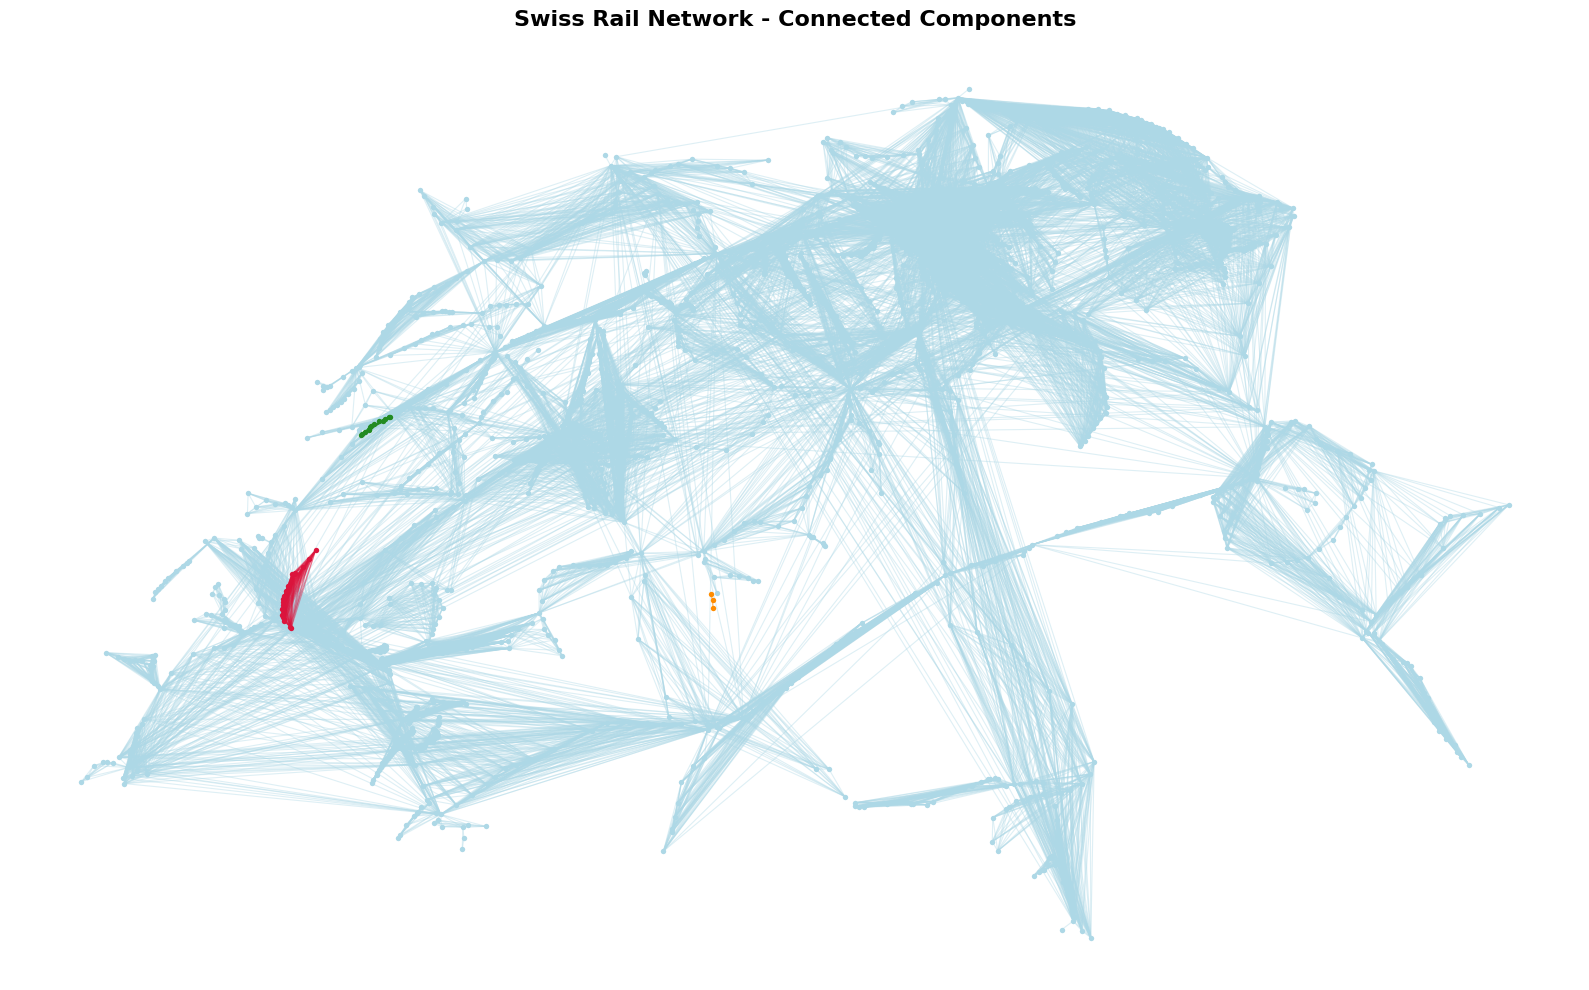

In [24]:
pos = {row['BPUIC']: (row['LONGITUDE'], row['LATITUDE']) for _, row in df_nodes.iterrows()}
fig, ax = plt.subplots(figsize=(16, 10), facecolor='white')

# Get connected components sorted by size (largest first)
components = sorted(nx.connected_components(G), key=len, reverse=True)

# Define high-contrast colors for the different components
custom_colors = ['lightblue', 'crimson', 'forestgreen', 'darkorange']

for idx, comp in enumerate(components):
    # Assign color, using modulo to avoid IndexError if components > len(custom_colors)
    comp_color = custom_colors[idx % len(custom_colors)]
    
    # Extract the subgraph for the current component
    subgraph = G.subgraph(comp)
    
    # Plot edges
    for u, v in subgraph.edges():
        if u in pos and v in pos:
            x = [pos[u][0], pos[v][0]]
            y = [pos[u][1], pos[v][1]]
            ax.plot(x, y, color=comp_color, alpha=0.4, linewidth=0.8)
    
    # Plot nodes
    x_coords = [pos[n][0] for n in comp if n in pos]
    y_coords = [pos[n][1] for n in comp if n in pos]
    
    # Only draw if there are valid coordinates
    if x_coords and y_coords:
        ax.scatter(x_coords, y_coords, s=15, color=comp_color, zorder=5, linewidths=0)

ax.set_title("Swiss Rail Network - Connected Components", fontsize=16, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

As expected, we can see 3 little connected components that are disconnected from the main network. Since the biggest component has around 98% of all nodes in the network, we will restric our study to this connected component. In this way, we pass from having to deal with the directed and disconnected original network to an undirected and connected network while still representing almost the whole original network. This simplifies the study and helps go into detail. From this point on, we will refer to this big connected component of the undirected version of the original network as our _network_, without constantly repeating how we obtained it from the original one or giving it a new name. It will be stored inside the new variable called G.

We remove the 3 small components and keep the biggest one in the next cell:

In [25]:
import networkx as nx

# We identify the nodes belonging to the largest connected component
largest_cc_nodes = max(nx.connected_components(G), key=len)

# We use .copy() to ensure the graph is mutable.
# Without it, G.subgraph() returns a read-only view.
G_main = G.subgraph(largest_cc_nodes).copy()


# Verification of the filtering process
original_count = G.number_of_nodes()
main_count = G_main.number_of_nodes()

print('---------------------VERIFICATION OF THE FILTERING PROCESS---------------------')
print(f"Nodes in original graph: {original_count}")
print(f"Nodes in main connected component: {main_count}")

######### CHANGING NAME OF THE NETWORK (to avoid writing G_main all the time in the rest of the notebook)######################
###############################################################################################################################
G_original = G.copy()   
G = G_main.copy() 
##############################################################################################################################
#NOW THE ORIGINAL NETWORK IS UNDER THE NAME G_original AND THE CURRENT NETWORK (biggest conected component of undirected graph) UNDER THE NAME G.

print(f'\n---------------------GENERAL INFORMATION OF THE NEW NETWORK --------------------- ')

n = G.number_of_nodes()
e = G.number_of_edges()

max_edges = n * (n - 1) / 2
density   = nx.density(G)  
sparsity  = 1 - density

print(f"Nodes:{n}")
print(f"Edges:{e}")
print(f"Max possible:{max_edges:.0f}")
print(f"Density:{density*100:.6f}%")
print(f"Sparsity:{sparsity*100:.6f}%")

---------------------VERIFICATION OF THE FILTERING PROCESS---------------------
Nodes in original graph: 1625
Nodes in main connected component: 1591

---------------------GENERAL INFORMATION OF THE NEW NETWORK --------------------- 
Nodes:1591
Edges:18248
Max possible:1264845
Density:1.442706%
Sparsity:98.557294%


Observe that we have removed 34 nodes, which is exactly the sum of the nodes of the three small strongly connected components that we detected on the directed graph. Now, we repeat some of the most important computations that we used for the original network and that can change the most after changing to the new network: centrality, clustering, and shortest paths.

###  RECALCULATION: Centrality study

In [26]:
# NetwrokX centrality metrics
deg_cent = nx.degree_centrality(G)
clo_cent = nx.closeness_centrality(G, distance='AVG_DURATION')
#clo_cent = nx.closeness_centrality(G)
bet_cent = nx.betweenness_centrality(G, weight='AVG_DURATION')
#bet_cent = nx.betweenness_centrality(G)

df_centrality = pd.DataFrame({
    'Degree': deg_cent,
    'Closeness': clo_cent,
    'Betweenness': bet_cent
}).reset_index().rename(columns={'index': 'BPUIC'})

# Merge with df_nodes to get the station names
df_report = df_centrality.merge(df_nodes[['BPUIC', 'STATION_NAME']], on='BPUIC', how='left')

# Reordering of the columns
cols = ['BPUIC', 'STATION_NAME', 'Degree', 'Closeness', 'Betweenness']
df_report = df_report[cols]


print("--- STATION CENTRALITY REPORT ---")

print("\nTOP 3: Most connected stations (Degree Centrality)")
print("Measures the proportion of stations to which the current station is directly connected.")
display(df_report.sort_values('Degree', ascending=False)[['STATION_NAME', 'Degree']].head(3))

print("\nBottom 3: Least connected stations (Degree Centrality)")
display(df_report.sort_values('Degree', ascending=True)[['STATION_NAME', 'Degree']].head(3))

print("\n\nTOP 3: Most central hubs (Closeness Centrality)")
print("Measures how fast you can reach all other stations from this one (shortest paths in terms of time).")
display(df_report.sort_values('Closeness', ascending=False)[['STATION_NAME', 'Closeness']].head(3))

print("\nBottom 3: Most isolated / Slowest (Closeness Centrality)")
display(df_report.sort_values('Closeness', ascending=True)[['STATION_NAME', 'Closeness']].head(3))

print("\n\nTOP 3: Bridge nodes / Bottlenecks (Betweenness Centrality)")
print("Measures how often this station acts as a mandatory pass-through in the shortest routes (in terms of time) between two other stations.")
display(df_report.sort_values('Betweenness', ascending=False)[['STATION_NAME', 'Betweenness']].head(3))

print("\nBottom 3: Dead-ends / Zero impact on routing (Betweenness Centrality)")
display(df_report.sort_values('Betweenness', ascending=True)[['STATION_NAME', 'Betweenness']].head(3))



--- STATION CENTRALITY REPORT ---

TOP 3: Most connected stations (Degree Centrality)
Measures the proportion of stations to which the current station is directly connected.


,STATION_NAME,Degree
0,Zürich HB,0.174214
553,Bern,0.113836
646,Olten,0.103774



Bottom 3: Least connected stations (Degree Centrality)


,STATION_NAME,Degree
1074,Stabio,0.000629
919,Herblingen,0.000629
1174,Basel St. Johann,0.000629




TOP 3: Most central hubs (Closeness Centrality)
Measures how fast you can reach all other stations from this one (shortest paths in terms of time).


...

,STATION_NAME,Closeness
502,Tirano,0.002847
501,Campocologno,0.002909
516,Campascio,0.002932




TOP 3: Bridge nodes / Bottlenecks (Betweenness Centrality)
Measures how often this station acts as a mandatory pass-through in the shortest routes (in terms of time) between two other stations.


,STATION_NAME,Betweenness
0,Zürich HB,0.351249
553,Bern,0.248459
647,Bern Wankdorf,0.179883



Bottom 3: Dead-ends / Zero impact on routing (Betweenness Centrality)


,STATION_NAME,Betweenness
1580,Innertkirchen Kraftwerk (Bahn),0.0
18,Trogen,0.0
1274,Luzern Littau,0.0


As we can see the centrality results have changed. But, in particular, even though some stations in the top 3 for each of the centrality measures have changed, where we see more changes is in the bottom 3 stations. This makes a lot of sense, because some of the least central stations in the originial network corresponded to nodes in the smallest connected components, and now we don't have them. As we will now see, the same happens for the eigenvector and katz centrality.

In [27]:
#LETS COMPUTE SOME OTHER CENTRALITIES: EIGEVECTOR CENTRALITY AND KATZ CENTRALITY
# Get largest eigenvalue for alpha
import numpy as np
eigenvalues = nx.adjacency_spectrum(G)
largest_eigenvalue = max(abs(eigenvalues))
print(f"Largest eigenvalue: {largest_eigenvalue:.4f}")
alpha = 0.8 / largest_eigenvalue
print(f"Alpha: {alpha:.4f}")

# Eigenvector centrality
try:
    eig_cent = nx.eigenvector_centrality(G, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge, try increasing max_iter")
    eig_cent = {node: 0 for node in G.nodes()}

# Katz centrality
try:
    katz_cent = nx.katz_centrality(G, alpha=alpha)
except nx.PowerIterationFailedConvergence:
    print("Katz centrality did not converge")
    katz_cent = {node: 0 for node in G.nodes()}

# Rebuild dataframe with all centralities
df_centrality = pd.DataFrame({
    'Degree': deg_cent,
    'Closeness': clo_cent,
    'Betweenness': bet_cent,
    'Eigenvector': eig_cent,
    'Katz': katz_cent
}).reset_index().rename(columns={'index': 'BPUIC'})

# Merge with df_nodes
df_report = df_centrality.merge(df_nodes[['BPUIC', 'STATION_NAME']], on='BPUIC', how='left')

# Reorder columns
cols = ['BPUIC', 'STATION_NAME', 'Degree', 'Closeness', 'Betweenness', 'Eigenvector', 'Katz']
df_report = df_report[cols]

print("\n\nTOP 3: Most influential stations (Eigenvector Centrality)")
print("Measures influence based on the quality of connections — being connected to well-connected stations matters more.")
display(df_report.sort_values('Eigenvector', ascending=False)[['STATION_NAME', 'Eigenvector']].head(3))

print("\nBottom 3: Least influential (Eigenvector Centrality)")
display(df_report.sort_values('Eigenvector', ascending=True)[['STATION_NAME', 'Eigenvector']].head(3))

print("\n\nTOP 3: Most influential stations (Katz Centrality)")
print("Similar to Eigenvector but also counts longer paths with a decay factor — more robust for directed graphs.")
display(df_report.sort_values('Katz', ascending=False)[['STATION_NAME', 'Katz']].head(3))

print("\nBottom 3: Least influential (Katz Centrality)")
display(df_report.sort_values('Katz', ascending=True)[['STATION_NAME', 'Katz']].head(3))

Largest eigenvalue: 49.4885
Alpha: 0.0162


TOP 3: Most influential stations (Eigenvector Centrality)
Measures influence based on the quality of connections — being connected to well-connected stations matters more.


,STATION_NAME,Eigenvector
0,Zürich HB,0.243499
672,Winterthur,0.177106
732,Zürich Oerlikon,0.165304



Bottom 3: Least influential (Eigenvector Centrality)


,STATION_NAME,Eigenvector
256,Le Locle Le Chalet,0.000002
257,Les Frêtes,0.000002
258,Les Brenets,0.000002




TOP 3: Most influential stations (Katz Centrality)
Similar to Eigenvector but also counts longer paths with a decay factor — more robust for directed graphs.


,STATION_NAME,Katz
0,Zürich HB,0.187372
672,Winterthur,0.130064
732,Zürich Oerlikon,0.118897



Bottom 3: Least influential (Katz Centrality)


,STATION_NAME,Katz
1482,Orsières,0.009273
1483,La Douay,0.009273
256,Le Locle Le Chalet,0.009422


### RECALCULATION: Clustering

In [28]:
triangles = nx.triangles(G)

total_triangles = sum(triangles.values()) // 3
print(f"Total triangles:{total_triangles}")

#Newman clustering measure
transitivity = nx.transitivity(G)
print(f"Transitivity: {transitivity:.4f}")

clustering = nx.clustering(G)

#Wats-Strogatz clustering measure
avg_clustering= nx.average_clustering(G)
print(f"Average clustering:{avg_clustering:.4f}")

print(f"# Nodes with clustering coefficient C = 0: {sum(1 for v in clustering.values() if v == 0)}")
print(f"# Nodes with clustering coefficient C = 1: {sum(1 for v in clustering.values() if v == 1)}")


Total triangles:125889
Transitivity: 0.5481
Average clustering:0.8901
# Nodes with clustering coefficient C = 0: 3
# Nodes with clustering coefficient C = 1: 1024


Very similar results to the ones obtained in the study of the original network as some computations were made with the undirected graph.

### RECALCULATION: Shortest path

Now we can compute the average shortest paths by connection and time without any problems, as the network is connected.

In [29]:
# Average Shortest Path by CONNECTIONS
avg_hops = nx.average_shortest_path_length(G)
print(f"Average shortest path by connection: {avg_hops:.4f}")

# Average Shortest Path by TIME (AVG_DURATION)
avg_time = nx.average_shortest_path_length(G, weight='AVG_DURATION')
print(f"Average shortest path bby time: {avg_time:.4f}")

Average shortest path by connection: 3.3570
Average shortest path bby time: 141.1577


The results, as expected are very similar to the ones we obtained previously in the notebook.

### Distance measures

We now compute the eccentricity and some distance measures of the graph: radius, diameter, center and periphery

- The **exentricity** of a node is the maximum shortest path from that node to any other.
- The **radius** is the minimum eccentricity across all nodes, meaning that the radius of a graph is the minimum of the maximum shortest path from a node.
- The **diameter** is the maximum eccentricity across all nodes, meaning that the radius of a graph is the maximum of the maximum shortest path from a node.
- The **center** is the set of nodes whose eccentricity equals the radius. These are the nodes that are closest to everything else.
- The **periphery** is the set of nodes whose eccentricity equals the diameter. These are the nodes that are furthest from everything else.

So in some sense the diameter and the periphery are analogous to the radius and center.in our case,

In [30]:
eccentricity = nx.eccentricity(G)
radius = nx.radius(G, eccentricity)
diameter = nx.diameter(G, eccentricity)
center = nx.center(G, eccentricity)
periphery = nx.periphery(G, eccentricity)

print(f"Radius: {radius}")
print(f"Diameter: {diameter}")
#print(f"Exentricity: {eccentricity}")
print(f"Center (eccentricity=radius): {len(center)} nodes")
print(f"Periphery (eccentricity=diameter): {len(periphery)} nodes")

Radius: 4
Diameter: 7
Center (eccentricity=radius): 46 nodes
Periphery (eccentricity=diameter): 10 nodes


INTERPRETATION.
- Radius: 4. The most central stations can reach any other station in the network with at most 4 train changes. From these stations, the entire Swiss rail network is always within 4 direct trains.
- Diameter: 7. The worst case journey in the network requires 7 train changes.
- Center: 46. 46 stations can reach the entire network in at most 4 train changes. These are the most transfer-efficient stations in the network.
- Periphery: 10. Only 10 stations require 7 train changes to reach the furthest point in the network. A very small periphery for a network of 1625 stations, probably meaning very few stations are truly remote. 

It can be also interesting to compute this not only by connections but travel time. That's what we do next.

In [31]:
# precompute weighted shortest paths once
sp = dict(nx.all_pairs_dijkstra_path_length(G, weight='AVG_DURATION'))

eccentricity_w = nx.eccentricity(G, sp=sp)
radius_w = nx.radius(G, e=eccentricity_w)
diameter_w = nx.diameter(G, e=eccentricity_w)
center_w = nx.center(G, e=eccentricity_w)
periphery_w = nx.periphery(G, e=eccentricity_w)

print(f"Radius: {radius_w:.2f} min")
print(f"Diameter: {diameter_w:.2f} min")
print(f"Center (eccentricity=radius): {len(center_w)} nodes")
print(f"Periphery (eccentricity=diameter): {len(periphery_w)} nodes")

Radius: 258.80 min
Diameter: 504.32 min
Center (eccentricity=radius): 1 nodes
Periphery (eccentricity=diameter): 2 nodes


INTERPRETATION:
- Radius: 258.80 min. The most central station can reach any other station in the network in at most ~4.3 hours.
- Diameter: 504.32 min. The two furthest stations are +-8.4 hours of travel time apart, the longest possible journey in the network.
- Center: 1 node. Only one station achieves this minimum eccentricity, making it the single most time-efficient hub in the entire network.
- Periphery: 2 nodes. Only 2 stations sit at maximum travel distance from the rest, confirming that extreme remoteness by time is very rare.

In this case we do expect very few nodes to be in the center and periphery of the graph because travel time varies more than train connections. For instance travel time depends on distance, max speed limits, stops at other stations etc, hile connections just on connections. So it's very difficult to have journeys lasting the same amount of time.

Now, since we have such a low amount of nodes for both categories, we can easily check which station is the most centric and which ones the most peripheric:

In [32]:
central_node = center_w[0]
info_centro = df_nodes[df_nodes['BPUIC'] == central_node][['STATION_NAME', 'MUNICIPALITY', 'COMPANY']]

print("\nInformation of the central node in terms of time:")
display(info_centro)


info_periphery = df_nodes[df_nodes['BPUIC'].isin(periphery_w)][['STATION_NAME', 'MUNICIPALITY', 'COMPANY']]

print("\nInformation of the peripheric nodes in terms of time:")
display(info_periphery)


Information of the central node in terms of time:


,STATION_NAME,MUNICIPALITY,COMPANY
620,Siebnen-Wangen,Wangen (SZ),Swiss Federal Railways SBB



Information of the peripheric nodes in terms of time:


,STATION_NAME,MUNICIPALITY,COMPANY
991,Masera,NaN,Società Subalpina di Imprese Ferroviare (Cento...
1516,Tirano,NaN,Rhätische Bahn


The central station is near Zürich, but it is surprising to see that the most central node does not belong to one of the most important cities in Switzerland.

On the other hand, we can see two stations without municipality and that do not belong to the main rail componay of the country. Therefore, we can say that the results are coherent with what we could expect in this case.

### Degree distributions

We now compute the assortativity and average neighbor degree of the graph to understand how stations connect with one another based on their similarities:
- The **assortativity coefficient** measures the tendency of nodes to connect to other nodes that are similar to them in some way.
- The **degree assortativity** (and the **degree Pearson correlation coefficient**) measures the tendency of nodes to connect to nodes with similar degrees. A positive value (assortative) means hubs tend to connect to other hubs. A negative value (disassortative) means hubs tend to connect to low-degree stations.
- The **attribute assortativity** measures this exact same tendency, but based on specific node attributes (in our case the `COMPANY`) rather than connections.
- The **average neighbor degree** calculates the average degree of the direct neighbors for each individual node.

In [33]:
print("--- ASSORTATIVITY METRICS ---")

# 1. Degree Assortativity
# degree_assortativity_coefficient and degree_pearson_correlation_coefficient 
# generally compute the same underlying metric for standard graphs.
deg_assortativity = nx.degree_assortativity_coefficient(G)
deg_pearson = nx.degree_pearson_correlation_coefficient(G)

print(f"Degree Assortativity Coefficient: {deg_assortativity:.4f}")
print(f"Degree Pearson Correlation:       {deg_pearson:.4f}")
print("  -> If > 0: Hubs connect to hubs. If < 0: Hubs connect to smaller stations.\n")

# 2. Attribute Assortativity (Categorical)
categorical_attr = 'COMPANY'
try:
    attr_assortativity = nx.attribute_assortativity_coefficient(G, categorical_attr)
    print(f"Attribute Assortativity ({categorical_attr}): {attr_assortativity:.4f}")
    print(f"  -> If > 0: Stations tend to connect to stations of the same {categorical_attr}.")
except KeyError:
    print(f"Skipping Attribute Assortativity: '{categorical_attr}' not found in node attributes.")

# 3. Numeric Assortativity
# Replace 'ELEVATION' with your actual numerical node attribute key (if you have one)
numeric_attr = 'ELEVATION' 
try:
    num_assortativity = nx.numeric_assortativity_coefficient(G, numeric_attr)
    print(f"Numeric Assortativity ({numeric_attr}):   {num_assortativity:.4f}")
    print(f"  -> If > 0: Stations connect to others with similar {numeric_attr} values.")
except KeyError:
    print(f"Skipping Numeric Assortativity: '{numeric_attr}' not found in node attributes.")


print("\n--- AVERAGE NEIGHBOR DEGREE ---")

# Returns a dictionary mapping each node to the average degree of its neighbors: {node: avg_deg}
avg_neighbor_degrees = nx.average_neighbor_degree(G)

# To draw network-wide conclusions, we can calculate the global average
overall_avg_neighbor_deg = sum(avg_neighbor_degrees.values()) / len(avg_neighbor_degrees)
print(f"Network-wide average of neighbor degrees: {overall_avg_neighbor_deg:.2f}")

--- ASSORTATIVITY METRICS ---
Degree Assortativity Coefficient: 0.1078
Degree Pearson Correlation:       0.1078
  -> If > 0: Hubs connect to hubs. If < 0: Hubs connect to smaller stations.

Attribute Assortativity (COMPANY): 0.7945
  -> If > 0: Stations tend to connect to stations of the same COMPANY.
Numeric Assortativity (ELEVATION):   0.6853
  -> If > 0: Stations connect to others with similar ELEVATION values.

--- AVERAGE NEIGHBOR DEGREE ---
Network-wide average of neighbor degrees: 33.76


INTERPRETATION.

- **Degree Assortativity**: 0.11. The network shows a slightly positive tendency for hubs to connect to other hubs.
- **Company Assortativity**: 0.80. We have obtained a high value that tells us that stations are mostly connected to others operated by the same company.
- **Elevation Assortativity**: 0.69. Stations have a strong tendency to connect to others at similar altitudes.
- **Average Neighbor Degree**: 33.35. On average, the stations adjacent to any given stop have 33 neighbours.

Finally we plot the degree histogram and analyze it.

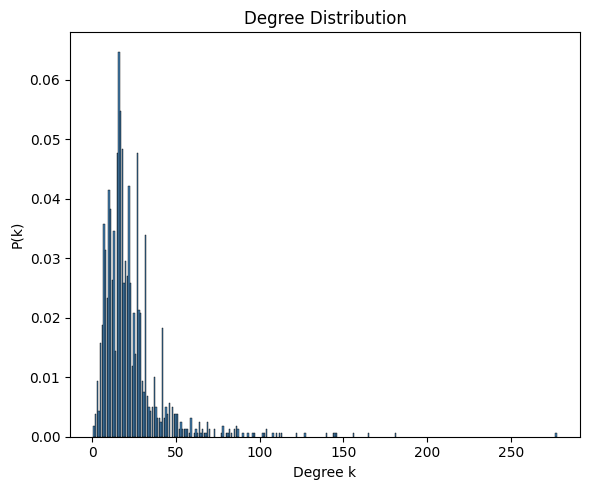

Average degree: 22.94
Max degree: 277
Min degree: 1

Comprobation:
Average degree × nodes: 36496
2 × edges:              36496


In [53]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# degree sequence
degrees = dict(G.degree())
degree_values = list(degrees.values())

# degree distribution
degree_counts = Counter(degree_values)
k_values = np.array(sorted(degree_counts.keys()))
pk_values = np.array([degree_counts[k] / len(degree_values) for k in k_values])

plt.figure(figsize=(6, 5))
plt.bar(k_values, pk_values, color='steelblue', edgecolor='black', linewidth=0.3)
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution')
plt.tight_layout()
plt.show()
avg_degree = np.mean(degree_values)
max_degree = np.max(degree_values)
min_degree = np.min(degree_values)

print(f"Average degree: {avg_degree:.2f}")
print(f"Max degree: {max_degree}")
print(f"Min degree: {min_degree}")

print(f'\nComprobation:')
print(f"Average degree × nodes: {avg_degree * G.number_of_nodes():.0f}")
print(f"2 × edges:              {2 * G.number_of_edges()}")

As we can see, the mean value of the degrees in the network is 22.94, meaning on average we have around 23 direct connections from each node. The stations with the most direct connections to other stations has 277 direct connections and the one with least only has 1 direct connection. From the histogram we can see that most stations have around 15 to 30 direct connections and that there are some stations with higher degree in the tail of the histogram. We now plot the log-log scale of these probabilities in order to see whether the degree distribution follows a power law (and with which exponent) and see the tail behavior more easily.

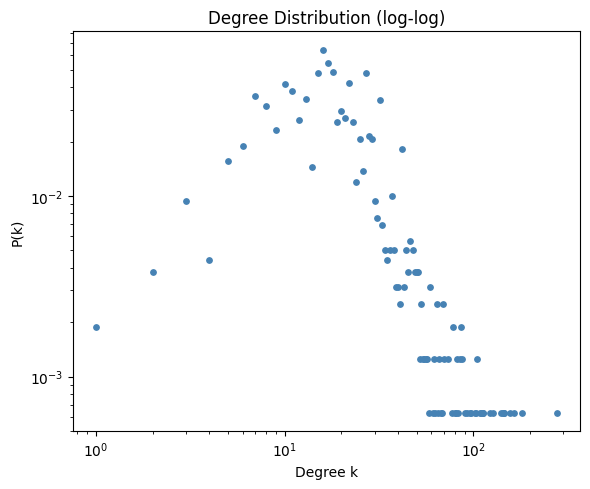

In [48]:
plt.figure(figsize=(6, 5))
plt.scatter(k_values, pk_values, color='steelblue', s=15)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution (log-log)')
plt.tight_layout()
plt.show()

The most striking thing that we can see in the plot are the two 'straight lines' at the tail of the distribution. As we saw in class, this is because at large values of the degree very few stations are observed: there is only one station with degree k in the network whenever k>100. Because of this, for every k>100, the observed probabilities are the same and that's why we see those 'straight lines'. 

These 'straight lines' in the tail make it difficult to obtain a good power-law exponent as linear regression treats all points equally and overfits this noisy region, giving an imprecise power-law exponent. To avoid this, we bin data with exponentially larger bins and compute the regression over the log-log binned data. 

NOTE: Unbinned data is represented with a circle and binned data with a square.

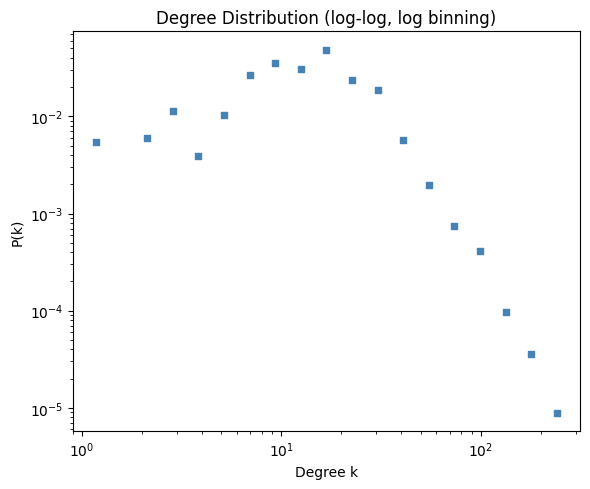

In [49]:
# logarithmic bins: 1, 2, 4, 8, 16, ...
bins = np.logspace(np.log10(min(degree_values)), np.log10(max(degree_values)), num=20)

counts, bin_edges = np.histogram(degree_values, bins=bins)
bin_widths = np.diff(bin_edges)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# normalize by bin width to get density
pk_binned = counts / (len(degree_values) * bin_widths)

# remove empty bins
mask = counts > 0
plt.figure(figsize=(6, 5))
plt.scatter(bin_centers[mask], pk_binned[mask], color='steelblue', s=15, marker='s')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution (log-log, log binning)')
plt.tight_layout()
plt.show()

Now, we will try to do the fitting. However, as we can see from the image, no line will fit the data appropriately. What we do is obtain the point with highest proabability and fit one line with points below this higest probability point and another one with those over it. In that way we can better describe the behaviour of the tail and of nodes with small values of k.

Peak at k=:16.825928683965948
Most common degree in peak: 16


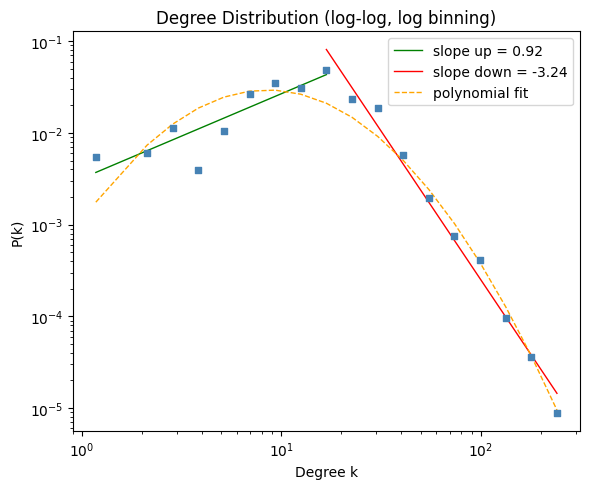

In [50]:
from scipy import stats
import numpy as np

log_k = np.log10(bin_centers[mask])
log_pk = np.log10(pk_binned[mask])

# split into increasing and decreasing parts — find the peak
peak_idx = np.argmax(log_pk)
peak = bin_centers[mask][peak_idx]
print(f'Peak at k=:{peak}')
most_common_degree = max(degree_counts, key=degree_counts.get)
print(f'Most common degree in peak: {most_common_degree}')

log_k_up = log_k[:peak_idx+1]
log_pk_up = log_pk[:peak_idx+1]
log_k_down = log_k[peak_idx:]
log_pk_down = log_pk[peak_idx:]

# fit lines to each part
slope_up, intercept_up, _, _, _ = stats.linregress(log_k_up, log_pk_up)
slope_down, intercept_down, _, _, _ = stats.linregress(log_k_down, log_pk_down)

# polynomial fit (degree 2)
poly_coeffs = np.polyfit(log_k, log_pk, 2)
poly_fit = np.polyval(poly_coeffs, log_k)

# plot
plt.figure(figsize=(6, 5))
plt.scatter(bin_centers[mask], pk_binned[mask], color='steelblue', s=15, zorder=3, marker='s')

plt.plot(10**log_k_up, 10**(intercept_up + slope_up * log_k_up),
         color='green', linewidth=1, label=f'slope up = {slope_up:.2f}')

plt.plot(10**log_k_down, 10**(intercept_down + slope_down * log_k_down),
         color='red', linewidth=1, label=f'slope down = {slope_down:.2f}')

plt.plot(10**log_k, 10**poly_fit,
         color='orange', linewidth=1, linestyle='--', label='polynomial fit')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree k')
plt.ylabel('P(k)')
plt.title('Degree Distribution (log-log, log binning)')
plt.legend()
plt.tight_layout()
plt.show()

We see: 
- **Increasing part (slope = +0.92, k < ~17)**: Most stations have between 10-20 connections. Very low degree stations (k=1-5) are actually rare, isolated terminals. The network has a clear minimum connectivity requirement, stations need enough connections to be useful.
- **Peak at k ≈ 17**: The most common station type has around 17 direct connections. This is the "typical" Swiss rail station, well connected but not a hub.
- **Decreasing part (slope = -3.24, k > ~17)**: The tail drops with γ ≈ 3.24 steeper than most scale-free networks (which have γ between 2 and 3). This means hubs are rare and not as dominant as in social or internet networks. Physical constraints of rail infrastructure prevent any station from accumulating hundreds of connections freely.

Finally we plot the CCDF also in the log log scale and fit it. In this case the power law fitting cannot be done to the whole CCDF either, so we use again two lines. In this way we have a better fit of both the tail and the lower values of the degree

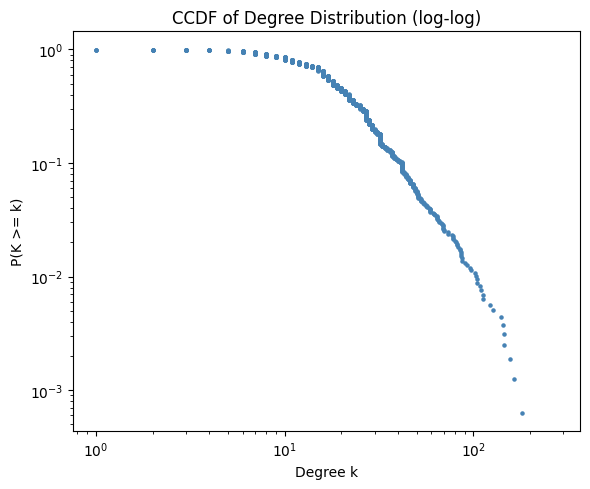

In [51]:
# CCDF — complementary cumulative distribution (P(K >= k))
sorted_degrees = np.sort(degree_values)
ccdf = 1 - np.arange(1, len(sorted_degrees)+1) / len(sorted_degrees)

plt.figure(figsize=(6, 5))
plt.scatter(sorted_degrees, ccdf, color='steelblue', s=5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree k')
plt.ylabel('P(K >= k)')
plt.title('CCDF of Degree Distribution (log-log)')
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.title(label: 'str', fontdict: 'dict[str, Any] | None' = None, loc: "Literal['left', 'center', 'right'] | None" = None, pad: 'float | None' = None, *, y: 'float | None' = None, **kwargs) -> 'Text'>

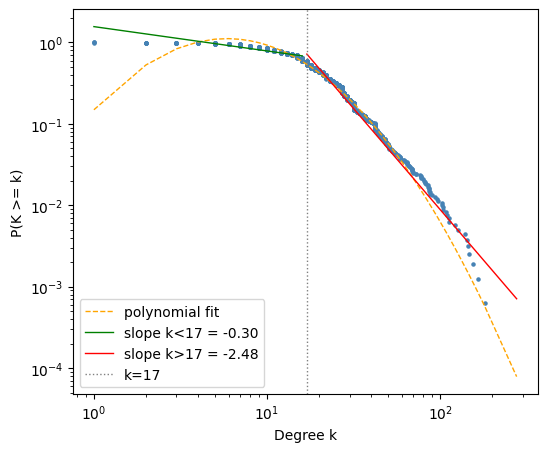

In [52]:
sorted_degrees = np.sort(degree_values)
ccdf = 1 - np.arange(1, len(sorted_degrees)+1) / len(sorted_degrees)

log_k = np.log10(sorted_degrees)
log_ccdf = np.log10(ccdf + 1e-10)

# split at k=17
split_idx = np.searchsorted(sorted_degrees, 17)

log_k_left = log_k[:split_idx]
log_ccdf_left = log_ccdf[:split_idx]
log_k_right = log_k[split_idx:]
log_ccdf_right = log_ccdf[split_idx:]

# fits
poly_coeffs = np.polyfit(log_k, log_ccdf, 2)
poly_fit = np.polyval(poly_coeffs, log_k)

slope_left, intercept_left, _, _, _ = stats.linregress(log_k_left, log_ccdf_left)
slope_right, intercept_right, _, _, _ = stats.linregress(log_k_right, log_ccdf_right)

plt.figure(figsize=(6, 5))
plt.scatter(sorted_degrees, ccdf, color='steelblue', s=5)
plt.plot(sorted_degrees, 10**poly_fit, color='orange', linewidth=1, linestyle='--', label='polynomial fit')
plt.plot(10**log_k_left, 10**(intercept_left + slope_left * log_k_left), color='green', linewidth=1, label=f'slope k<17 = {slope_left:.2f}')
plt.plot(10**log_k_right, 10**(intercept_right + slope_right * log_k_right), color='red', linewidth=1, label=f'slope k>17 = {slope_right:.2f}')
plt.axvline(17, color='gray', linestyle=':', linewidth=1, label='k=17')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Degree k')
plt.ylabel('P(K >= k)')
plt.legend()
plt.title

INTERPRETATION: 
- **Left part (k < 17), green line**: The CCDF is nearly flat or slowly decreasing — most stations have at least 17 connections, meaning the network has a high baseline connectivity. Low degree stations are relatively rare.
- **Right part (k > 17), red line:** The CCDF drops fast in the tail of the distribution. The slope here is ≈ -2.48. Stations with more than 17 connections become rapidly rarer.